# Road Sign Detection MVP
**Two-model ensemble:** Speed Signs (YOLOv8s) + LISA 47-class (YOLOv8n) fused with Weighted Boxes Fusion.

### Run order
1. GPU Check
2. Install dependencies
3. Mount Drive & load models
4. Download LISA dataset
5. Dataset EDA
6. Evaluate each model
7. Ensemble inference on test images
8. Results summary
9. Gradio web app (image + dashcam video)

## 1 — GPU Check
> **If this cell raises an error**, go to `Runtime -> Change runtime type -> T4 GPU` then re-run.

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected.\n"
        "Go to Runtime -> Change runtime type -> T4 GPU, then re-run all cells."
    )

print(f"GPU ready: {torch.cuda.get_device_name(0)}")

GPU ready: Tesla T4


## 2 — Install Dependencies

In [2]:
!pip install ultralytics ensemble-boxes roboflow opencv-python matplotlib gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which is incompatible.


## 3 — Mount Drive & Load Trained Models

In [3]:
from google.colab import drive, userdata
from ultralytics import YOLO

drive.mount('/content/drive')

SPEED_MODEL_PATH = "/content/drive/My Drive/runs/train/new_dataset_yolo8s_30epochs5/weights/best.pt"
LISA_MODEL_PATH  = "/content/drive/My Drive/runs/train/Lisa_yolo8n_30epochs/weights/best.pt"

model_speed = YOLO(SPEED_MODEL_PATH)
model_lisa  = YOLO(LISA_MODEL_PATH)

print(f"Speed model classes : {len(model_speed.names)}")
print(f"LISA  model classes : {len(model_lisa.names)}")
print("Models loaded successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Speed model classes : 15
LISA  model classes : 47
Models loaded successfully.


## 4 — Download LISA Dataset (skips if already present)

**Setup your Roboflow API key as a Colab Secret:**
1. Click the key icon in the left sidebar
2. Add secret name `ROBOFLOW_KEY` and paste your API key
3. Toggle the access switch to ON

In [4]:
import os, re
from roboflow import Roboflow

DATASET_PATH = "/content/LISA-road-signs-1"
DATA_YAML    = f"{DATASET_PATH}/data.yaml"

if not os.path.exists(DATASET_PATH):
    roboflow_key = userdata.get("ROBOFLOW_KEY")
    rf = Roboflow(api_key=roboflow_key)
    project = rf.workspace("dakota-smith").project("lisa-road-signs")
    project.version(1).download("yolov8")
else:
    print("Dataset already present, skipping download.")

# Fix relative paths in data.yaml
with open(DATA_YAML) as f:
    content = f.read()
content = re.sub(r'\.\.[\\/]', f'{DATASET_PATH}/', content)
with open(DATA_YAML, "w") as f:
    f.write(content)
print("data.yaml paths fixed.")

with open(DATA_YAML) as f:
    print(f.read())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LISA-road-signs-1 in yolov8:: 100%|██████████| 23174/23174 [00:02<00:00, 9169.29it/s] 

data.yaml paths fixed.
names:
- addedLane
- curveLeft
- curveRight
- dip
- doNotEnter
- doNotPass
- intersection
- keepRight
- laneEnds
- merge
- noLeftTurn
- noRightTurn
- pedestrianCrossing
- rampSpeedAdvisory20
- rampSpeedAdvisory35
- rampSpeedAdvisory40
- rampSpeedAdvisory45
- rampSpeedAdvisory50
- rampSpeedAdvisoryUrdbl
- rightLaneMustTurn
- roundabout
- school
- schoolSpeedLimit25
- signalAhead
- slow
- speedLimit15
- speedLimit25
- speedLimit30
- speedLimit35
- speedLimit40
- speedLimit45
- speedLimit50
- speedLimit55
- speedLimit65
- speedLimitUrdbl
- stop
- stopAhead
- thruMergeLeft
- thruMergeRight
- thruTrafficMergeLeft
- truckSpeedLimit55
- turnLeft
- turnRight
- yield
- yieldAhead
- zoneAhead25
- zoneAhead45
nc: 47
roboflow:
  license: CC BY 4.0
  project: lisa-road-signs
  url: https://universe.roboflow.com/dakota-smith/lisa-road-signs/dataset/1
  version: 1
  workspace: dakota-smith
test: /content/LISA-road-signs-1/test/images
train: /content/LISA-road-signs-1/train/imag

## 5 — Dataset EDA: Class Distribution

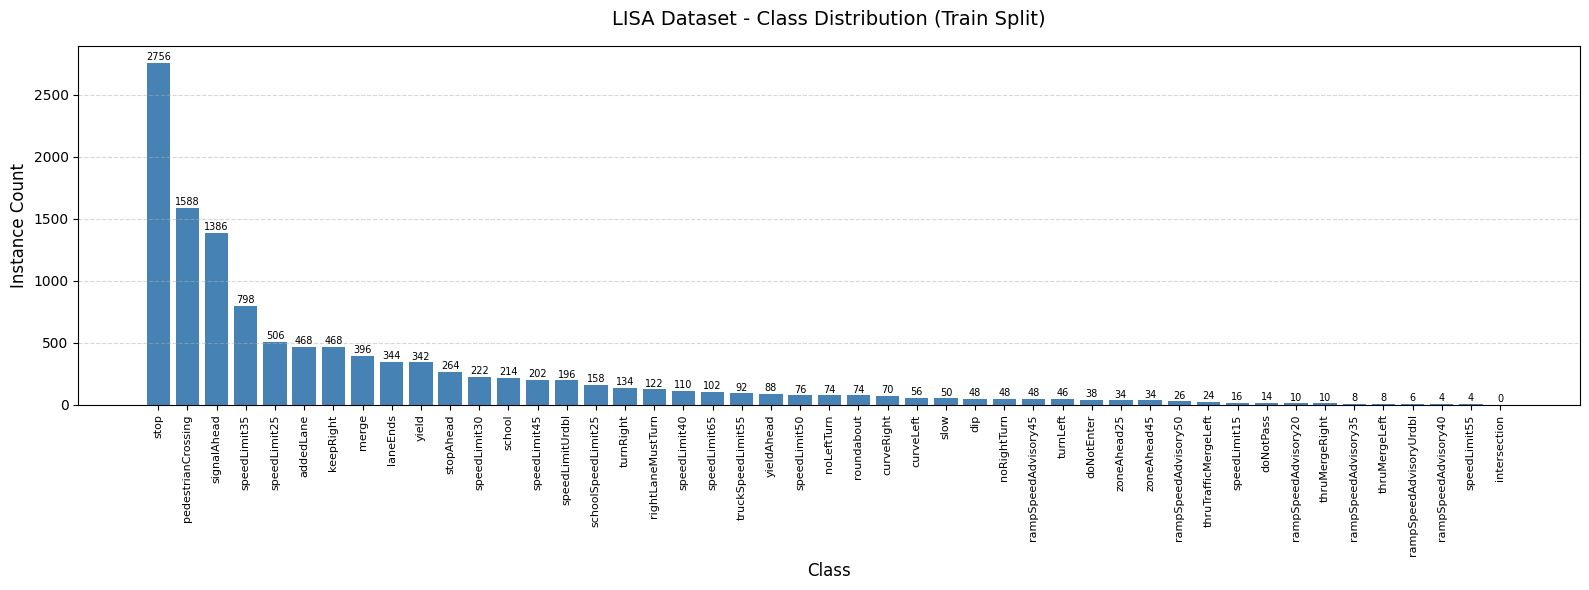

Total classes with instances: 46


In [5]:
import yaml
import matplotlib.pyplot as plt

with open(DATA_YAML) as f:
    data = yaml.safe_load(f)
class_names = data["names"]

counts = {name: 0 for name in class_names}
labels_dir = f"{DATASET_PATH}/train/labels/"

for fname in os.listdir(labels_dir):
    if fname.endswith(".txt"):
        with open(os.path.join(labels_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[class_names[int(parts[0])]] += 1

counts = dict(sorted(counts.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(counts.keys(), counts.values(), color="steelblue")
ax.set_title("LISA Dataset - Class Distribution (Train Split)", fontsize=14, pad=15)
ax.set_ylabel("Instance Count", fontsize=12)
ax.set_xlabel("Class", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, str(h),
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total classes with instances: {sum(1 for v in counts.values() if v > 0)}")

## 6 — Evaluate Each Model
Adding `plots=True` auto-generates a confusion matrix saved to `runs/detect/val/`.

In [6]:
print("=" * 50)
print("SPEED SIGN MODEL (YOLOv8s) - Test Set Metrics")
print("=" * 50)

speed_metrics = model_speed.val(
    data="/content/drive/My Drive/car/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    device=0
)
print(f"\nmAP@50      : {speed_metrics.box.map50:.4f}")
print(f"mAP@50-95   : {speed_metrics.box.map:.4f}")
print(f"Precision   : {speed_metrics.box.mp():.4f}")
print(f"Recall      : {speed_metrics.box.mr():.4f}")

SPEED SIGN MODEL (YOLOv8s) - Test Set Metrics
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.0±0.0 MB/s, size: 23.5 KB)
val: Scanning /content/drive/MyDrive/car/test/labels.cache... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 116.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 2.2it/s 18.0s
                   all        638        770      0.911      0.848      0.921      0.777
           Green Light         77        110      0.976      0.749      0.914      0.541
             Red Light         71         94      0.857      0.639      0.768      0.492
        Speed Limit 10          2          3      0.466      0.667      0.624      0.457
       Speed Limit 100         45         46      0.955      0.915      0.981      0.8

TypeError: 'numpy.float64' object is not callable

In [7]:
print("=" * 50)
print("SPEED SIGN MODEL (YOLOv8s) - Test Set Metrics")
print("=" * 50)

speed_metrics = model_speed.val(
    data="/content/drive/My Drive/car/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    device=0
)
print(f"\nmAP@50      : {speed_metrics.box.map50:.4f}")
print(f"mAP@50-95   : {speed_metrics.box.map:.4f}")
print(f"Precision   : {speed_metrics.box.mp:.4f}")
print(f"Recall      : {speed_metrics.box.mr:.4f}")

SPEED SIGN MODEL (YOLOv8s) - Test Set Metrics
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 6.8±4.3 MB/s, size: 17.1 KB)
val: Scanning /content/drive/MyDrive/car/test/labels.cache... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 243.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 4.9it/s 8.1s
                   all        638        770      0.911      0.848      0.921      0.777
           Green Light         77        110      0.976      0.749      0.914      0.541
             Red Light         71         94      0.857      0.639      0.768      0.492
        Speed Limit 10          2          3      0.466      0.667      0.624      0.457
       Speed Limit 100         45         46      0.955      0.915      0.981      0.855
       Speed Limit 110         21         21      0.891      0.857       0.87 

In [8]:
print("=" * 50)
print("LISA MODEL (YOLOv8n) - Test Set Metrics")
print("=" * 50)

lisa_metrics = model_lisa.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    plots=True,
    device=0
)
print(f"\nmAP@50      : {lisa_metrics.box.map50:.4f}")
print(f"mAP@50-95   : {lisa_metrics.box.map:.4f}")
print(f"Precision   : {lisa_metrics.box.mp:.4f}")
print(f"Recall      : {lisa_metrics.box.mr:.4f}")

LISA MODEL (YOLOv8n) - Test Set Metrics
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,014,813 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 942.2±508.5 MB/s, size: 22.9 KB)
val: Scanning /content/LISA-road-signs-1/test/labels... 662 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 662/662 2.2Kit/s 0.3s
val: New cache created: /content/LISA-road-signs-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 4.8it/s 8.7s
                   all        662        773      0.897      0.914       0.94      0.787
             addedLane         25         27      0.963      0.973      0.991      0.824
             curveLeft          2          2      0.861          1      0.995      0.846
            curveRight          7          7          1      0.852      0.995      0.812
                   dip      

## 7 — Ensemble Inference on Test Images
Uses **Weighted Boxes Fusion (WBF)** with correctly normalized box coordinates.

In [9]:
import cv2
import numpy as np
from ensemble_boxes import weighted_boxes_fusion
from PIL import Image
from IPython.display import display

CONF_THRESHOLD = 0.4
IOU_THRESHOLD  = 0.5

def annotate_frame(img_bgr):
    h, w = img_bgr.shape[:2]
    r_speed = model_speed.predict(img_bgr, save=False, imgsz=640, verbose=False, device=0)[0]
    r_lisa  = model_lisa.predict(img_bgr,  save=False, imgsz=640, verbose=False, device=0)[0]

    def extract(result):
        boxes  = result.boxes.xyxy.cpu().numpy()
        scores = result.boxes.conf.cpu().numpy()
        labels = result.boxes.cls.cpu().numpy()
        if len(boxes) == 0:
            return np.zeros((0, 4)), np.array([]), np.array([])
        norm = boxes.copy().astype(float)
        norm[:, [0, 2]] /= w
        norm[:, [1, 3]] /= h
        return np.clip(norm, 0, 1), scores, labels

    boxes_list, scores_list, labels_list = zip(extract(r_speed), extract(r_lisa))
    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        list(boxes_list), list(scores_list), list(labels_list),
        weights=[1.0, 1.0], iou_thr=IOU_THRESHOLD, skip_box_thr=CONF_THRESHOLD
    )

    out = img_bgr.copy()
    for box, score, label in zip(fused_boxes, fused_scores, fused_labels):
        x1, y1 = int(box[0]*w), int(box[1]*h)
        x2, y2 = int(box[2]*w), int(box[3]*h)
        cls_name = model_lisa.names.get(int(label), model_speed.names.get(int(label), str(int(label))))
        label_text = f"{cls_name} {score:.2f}"
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 200, 50), 2)
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1 - th - 6), (x1 + tw + 4, y1), (0, 200, 50), -1)
        cv2.putText(out, label_text, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    return out

def run_ensemble(image_path, show=True, save_dir=None):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    out = annotate_frame(img)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        cv2.imwrite(os.path.join(save_dir, os.path.basename(str(image_path))), out)
    if show:
        display(Image.fromarray(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)))
    return out

print("Ensemble functions ready.")

Ensemble functions ready.


Running ensemble on 10 random test images...

  merge_1323821565-avi_image11_png.rf.4df2e69b5647901b27ed3219d63f65f9.jpg


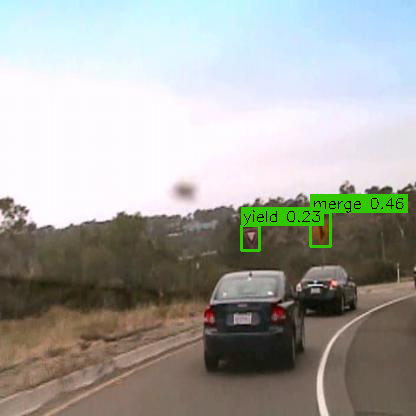

  stop_1330546169-avi_image24_png.rf.6656461c407e6c6c96f191d54b8c07d4.jpg


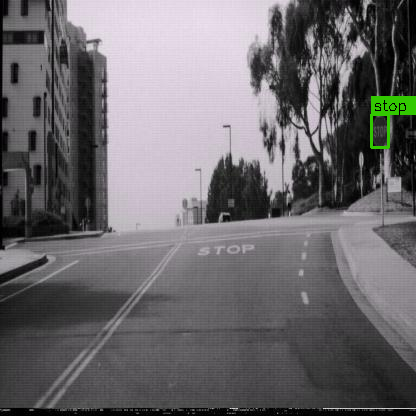

  curveRight_1333396823-avi_image10_png.rf.945baf2241247028ce0152ec102dce37.jpg


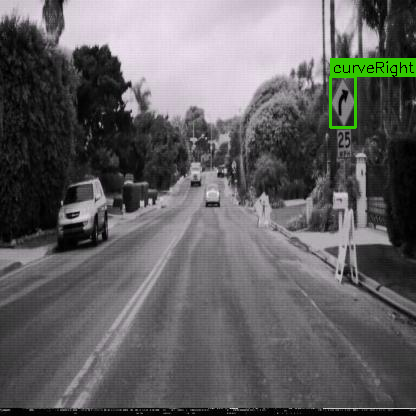

  signalAhead_1323820257-avi_image2_png.rf.776c04a0fa77c67767f401060c37e5fb.jpg


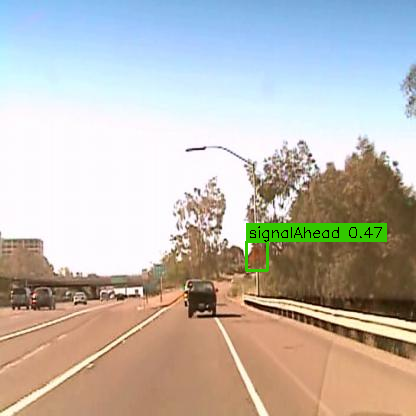

  stop_1323812778-avi_image14_png.rf.0b695a3d93981addcbdc780222dc09a3.jpg


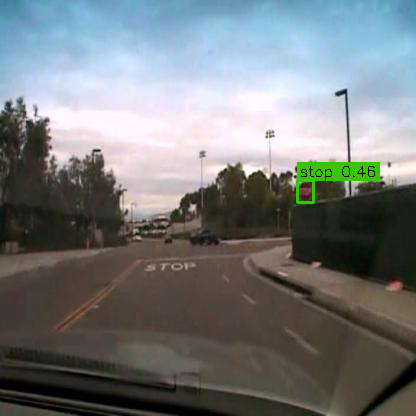

  pedestrianCrossing_1333397756-avi_image9_png.rf.f5ee412a40de5ba56edf2222b5ad178a.jpg


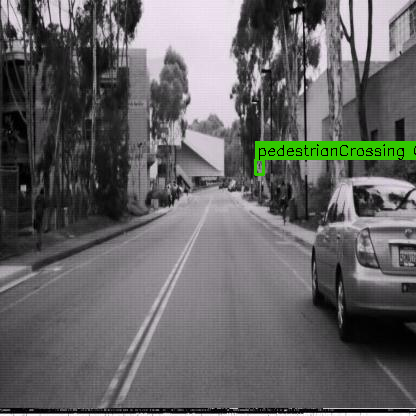

  pedestrian_1323821060-avi_image6_png.rf.ced86f9537249b54064dc92381319378.jpg


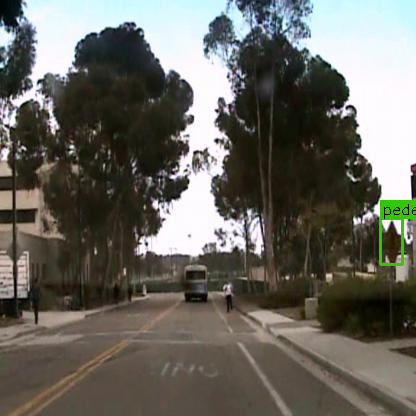

  truckSpeedLimit_1331866739-avi_image2_png.rf.78f9416341c3f01e7860c88ec3448118.jpg


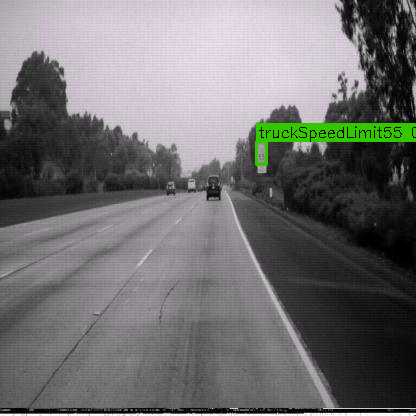

  speedLimit_1331866345-avi_image12_png.rf.44676c79c14fbae69eebbf8ce8387db5.jpg


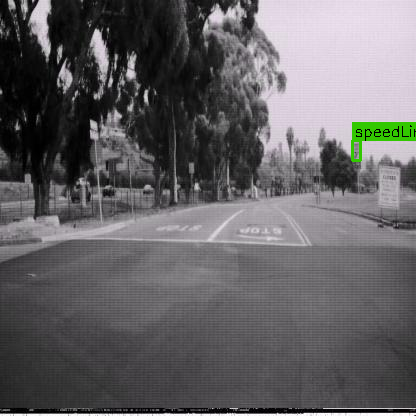

  stop_1333388384-avi_image10_png.rf.bb6f551c0c206680540cc155e7a85d90.jpg


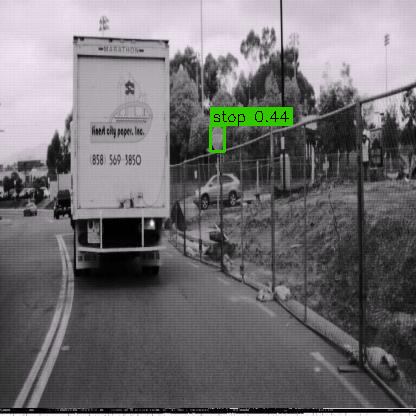


Done. Results saved to: /content/drive/My Drive/runs/ensemble_results


In [10]:
import random
from pathlib import Path

TEST_DIR  = f"{DATASET_PATH}/test/images"
SAVE_DIR  = "/content/drive/My Drive/runs/ensemble_results"
N_SAMPLES = 10

all_images = list(Path(TEST_DIR).glob("*.jpg")) + list(Path(TEST_DIR).glob("*.png"))
selected   = random.sample(all_images, min(N_SAMPLES, len(all_images)))

print(f"Running ensemble on {len(selected)} random test images...\n")
for img_path in selected:
    print(f"  {img_path.name}")
    run_ensemble(img_path, show=True, save_dir=SAVE_DIR)

print(f"\nDone. Results saved to: {SAVE_DIR}")

## 8 — Results Summary

In [ ]:
SEP = '=' * 62
DAT = '-' * 62
print('\n' + SEP)
print('       ROAD SIGN DETECTION - RESULTS SUMMARY')
print(SEP)
header = f"{'Metric':<20} {'Speed (YOLOv8s)':>20} {'LISA (YOLOv8n)':>20}"
print(header)
print(DAT)
print(f"{'mAP@50':<20} {speed_metrics.box.map50:>20.4f} {lisa_metrics.box.map50:>20.4f}")
print(f"{'mAP@50-95':<20} {speed_metrics.box.map:>20.4f} {lisa_metrics.box.map:>20.4f}")
print(f"{'Precision':<20} {speed_metrics.box.mp:>20.4f} {lisa_metrics.box.mp:>20.4f}")
print(f"{'Recall':<20} {speed_metrics.box.mr:>20.4f} {lisa_metrics.box.mr:>20.4f}")
print(f"{'Classes':<20} {len(model_speed.names):>20} {len(model_lisa.names):>20}")
print(SEP)
print('Ensemble : Weighted Boxes Fusion (WBF)')
print(f'Conf thr : {CONF_THRESHOLD}  |  IoU thr : {IOU_THRESHOLD}')
print(SEP)

## 9 — Gradio Web App
Supports **image upload** and **dashcam video upload**.

Run this cell and click the **public URL** to open the demo in any browser — shareable with anyone, no Colab access needed.

In [11]:
import gradio as gr
import tempfile

def predict_image(pil_image):
    if pil_image is None:
        return None
    img_bgr = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    out_bgr = annotate_frame(img_bgr)
    return Image.fromarray(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))

def predict_video(video_path):
    if video_path is None:
        return None
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError("Could not open video file.")
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out_file = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
    writer = cv2.VideoWriter(
        out_file.name, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height)
    )
    FRAME_SKIP = 2
    last_frame = None
    frame_idx  = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % FRAME_SKIP == 0:
            last_frame = annotate_frame(frame)
        writer.write(last_frame if last_frame is not None else frame)
        frame_idx += 1
    cap.release()
    writer.release()
    return out_file.name

with gr.Blocks(title="Road Sign Detection", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        "# Road Sign Detection\n"
        "**Two-model ensemble:** YOLOv8s (speed signs) + YOLOv8n (LISA 47-class), "
        "fused with Weighted Boxes Fusion.\n\n"
        "Upload an image or a dashcam video clip to run detection."
    )
    with gr.Tabs():
        with gr.TabItem("Image"):
            with gr.Row():
                img_input  = gr.Image(type="pil", label="Upload Image")
                img_output = gr.Image(type="pil", label="Detections")
            img_btn = gr.Button("Detect Signs", variant="primary")
            img_btn.click(fn=predict_image, inputs=img_input, outputs=img_output)
            gr.Examples(
                examples=[[str(p)] for p in list(Path(TEST_DIR).glob("*.jpg"))[:6]],
                inputs=img_input,
                label="Example test images"
            )
        with gr.TabItem("Dashcam Video"):
            gr.Markdown(
                "Upload a dashcam video (mp4, avi, mov). "
                "The model processes every other frame and returns a fully annotated video.\n\n"
                "> Tip: Keep clips under 30 seconds for fastest results on Colab free GPU."
            )
            with gr.Row():
                vid_input  = gr.Video(label="Upload Dashcam Video")
                vid_output = gr.Video(label="Annotated Output")
            vid_btn = gr.Button("Process Video", variant="primary")
            vid_btn.click(fn=predict_video, inputs=vid_input, outputs=vid_output)
    gr.Markdown(
        "---\n"
        "| Model | Architecture | Classes | mAP@50 |\n"
        "|---|---|---|---|\n"
        "| Speed Signs | YOLOv8s | 15 | 93.99% |\n"
        "| LISA Road Signs | YOLOv8n | 47 | - |\n"
    )

demo.launch(share=True, debug=False)

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1b9b8d0cc5dccafe11.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
!pip install yt-dlp -q

!yt-dlp -f "best[ext=mp4][height<=1080]" \
    "https://www.youtube.com/watch?v=8kOehYFpUDc" \
    -o "/content/dashcam_raw.mp4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 61.3 MB/s eta 0:00:00
[youtube] Extracting URL: https://www.youtube.com/watch?v=8kOehYFpUDc
[youtube] 8kOehYFpUDc: Downloading webpage
[youtube] 8kOehYFpUDc: Downloading android vr player API JSON
[info] 8kOehYFpUDc: Downloading 1 format(s): 18
[download] Destination: /content/dashcam_raw.mp4
[download] 100% of   36.27MiB in 00:00:04 at 8.52MiB/s


In [13]:
!ffmpeg -i /content/dashcam_raw.mp4 \
    -ss 0 -t 45 \
    -c:v libx264 -c:a aac \
    -y /content/dashcam_trimmed.mp4

print("Trimmed clip ready at /content/dashcam_trimmed.mp4")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [14]:
annotated_path = predict_video("/content/dashcam_trimmed.mp4")
print(f"Annotated video saved to: {annotated_path}")

Annotated video saved to: /tmp/tmpzrbao86y.mp4


In [15]:
!ffmpeg -i "{annotated_path}" \
    -vf "fps=10,scale=800:-1:flags=lanczos" \
    -y /content/demo.gif

print("GIF ready at /content/demo.gif")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [16]:
from google.colab import files
files.download(annotated_path)   # the .mp4
files.download("/content/demo.gif")  # the GIF for README

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>